In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import roc_auc_score, precision_recall_curve, RocCurveDisplay
from lightgbm import LGBMClassifier
from sklearn.calibration import CalibratedClassifierCV
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import pandas as pd
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, matthews_corrcoef,
    cohen_kappa_score, balanced_accuracy_score, 
    classification_report, brier_score_loss, log_loss
)
import numpy as np

### Carregando base de dados

In [2]:
df =pd.read_parquet('processed/df_hepat_processed_v1.parquet',engine='fastparquet')


### Selecionar variáveis relevantes para triagem


In [3]:

triage_features = [
    'NU_IDADE_N','CS_SEXO','CS_GESTANT','CS_RACA','CS_ESCOL_N',
    'ID_OCUPA_N','CON_AREA','CON_AMBIEN',
    'ANT_CB_LAM','ANT_CB_CRI','ANT_CB_SIN','ANT_CB_COR','ANT_CB_ROE',
    'ANT_CB_TER','ANT_CB_LIX','ANT_CB_OUT','ANT_ANIMAI','ANT_HUMANO',
    'CLI_FEBRE','CLI_MIALGI','CLI_CEFALE','CLI_PROST','CLI_CONGES',
    'CLI_PANTUR','CLI_VOMITO','CLI_DIARRE','CLI_ICTERI','CLI_RENAL',
    'CLI_RESPIR','CLI_CARDIA','CLI_HEMOPU','CLI_HEMORR','CLI_MENING',
    'CLI_OUTROS','SG_UF', 'baixa_escolaridade','raca_vulneravel','faixa_vulneravel',
    'vulnerabilidade_social', 'nivel_vulnerabilidade','mes_sintomas','estacao', 'periodo_chuvoso'
]



target_col = 'CLASSI_FIN'  # rótulo: confirmado vs descartado

if target_col == 'CLASSI_FIN':
    df = df[df['CLASSI_FIN'].isin(['Confirmado', 'Descartado'])].copy()

    # Criar variável alvo binária
    df['alvo'] = df['CLASSI_FIN'].map({
        'Confirmado': 1,
        'Descartado': 0
    })

X_data=df[triage_features]
y_data = df['alvo']



### Pré-processamento


In [4]:

# Variáveis numéricas
num_cols = X_data.select_dtypes(include=['int64', 'float64']).columns

# Variáveis categóricas (strings, objetos ou categorias)
cat_cols = X_data.select_dtypes(include=['object', 'category']).columns


# Pré-processador com OneHotEncoder
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ],
    remainder='passthrough'
)

### Modelo base e calibração (LightGBM)


In [5]:
model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    tree_method="hist"   # CPU seguro
)

clf = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('model', CalibratedClassifierCV(model, method='isotonic', cv=3))
])


### Treinamento e validação

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X_data, y_data,
    test_size=0.25, stratify=y_data, random_state=42
)

clf.fit(X_train, y_train)


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('cat', ...)]"
,remainder,'passthrough'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


### Curvas precision e Recall

ROC-AUC: 0.936


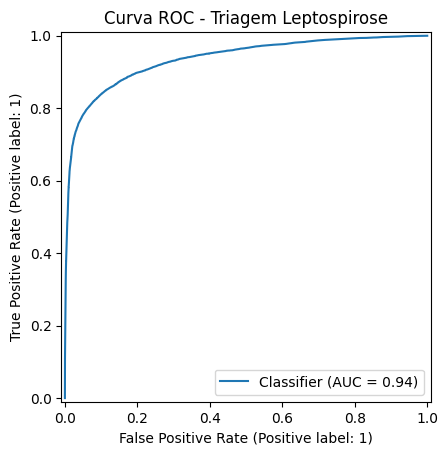

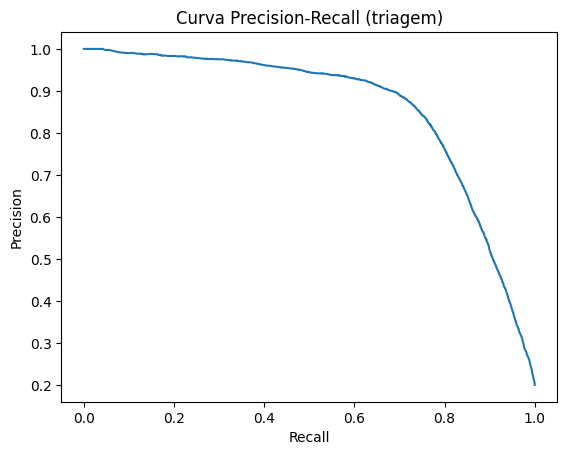

Limiar sugerido para ≥85% recall: 0.00


In [7]:
y_proba = clf.predict_proba(X_test)[:, 1]
auc = roc_auc_score(y_test, y_proba)
print(f"ROC-AUC: {auc:.3f}")

# Curva ROC
RocCurveDisplay.from_predictions(y_test, y_proba)
plt.title("Curva ROC - Triagem Leptospirose")
plt.show()

# Curva Precision-Recall
precision, recall, thr = precision_recall_curve(y_test, y_proba)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Curva Precision-Recall (triagem)")
plt.show()

# Avaliar limiar de decisão para sensibilidade alta
cutoff = thr[np.argmax(recall > 0.85)]
print(f"Limiar sugerido para ≥85% recall: {cutoff:.2f}")

### Matriz de confusão

C:\Users\diego\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\diego\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\diego\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


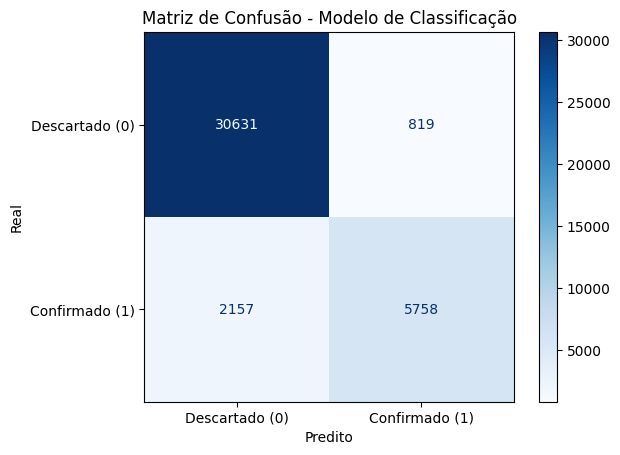

In [8]:

y_pred = clf.predict(X_test)        # previsões do seu modelo

# Gerar a matriz de confusão
cm = confusion_matrix(y_test, y_pred)

# Rótulos legíveis para o gráfico
labels = ['Descartado (0)', 'Confirmado (1)']

# Plotar a matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')

plt.title("Matriz de Confusão - Modelo de Classificação")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()


### Curva de calibração

C:\Users\diego\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\diego\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\diego\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


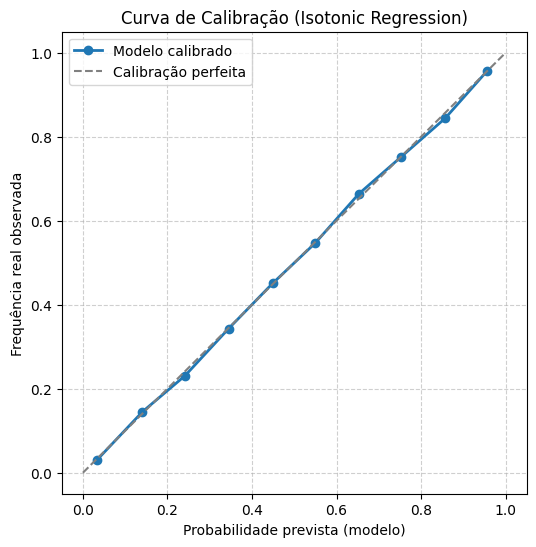

In [33]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve

# --- Probabilidades previstas e valores reais ---
y_true = y_test  # substitua pelo vetor real
y_proba = clf.predict_proba(X_test)[:, 1]  # probabilidade da classe positiva

# --- 1️⃣ Calcular curva de calibração ---
prob_true, prob_pred = calibration_curve(y_true, y_proba, n_bins=10, strategy='uniform')

# --- 2️⃣ Plotar ---
plt.figure(figsize=(6,6))
plt.plot(prob_pred, prob_true, marker='o', linewidth=2, label='Modelo calibrado')
plt.plot([0, 1], [0, 1], linestyle='--', color='gray', label='Calibração perfeita')
plt.title("Curva de Calibração (Isotonic Regression)")
plt.xlabel("Probabilidade prevista (modelo)")
plt.ylabel("Frequência real observada")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


### Análise de falso positio e falso negativo

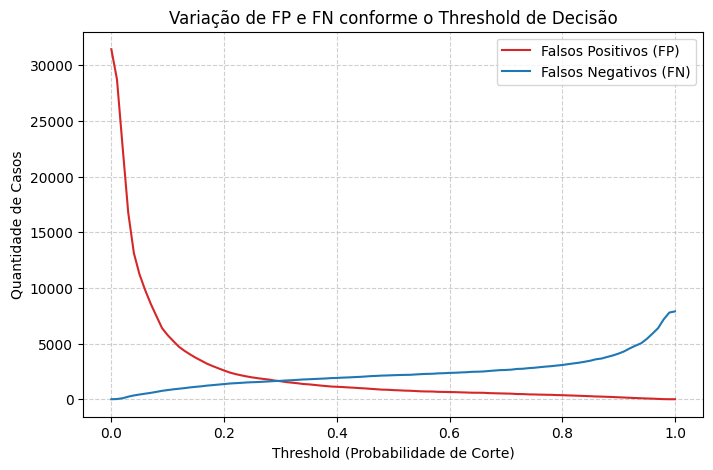

In [21]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# --- 2️⃣ Avaliar FP e FN para thresholds de 0.0 a 1.0 ---
thresholds = np.linspace(0, 1, 101)
fp_list, fn_list = [], []

for t in thresholds:
    y_pred = (y_proba >= t).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
    fp_list.append(fp)
    fn_list.append(fn)

# --- 3️⃣ Montar DataFrame ---
df_threshold = pd.DataFrame({
    'threshold': thresholds,
    'false_positives': fp_list,
    'false_negatives': fn_list
})

# --- 4️⃣ Plotar ---
plt.figure(figsize=(8,5))
plt.plot(df_threshold['threshold'], df_threshold['false_positives'], label='Falsos Positivos (FP)', color='tab:red')
plt.plot(df_threshold['threshold'], df_threshold['false_negatives'], label='Falsos Negativos (FN)', color='tab:blue')
plt.xlabel('Threshold (Probabilidade de Corte)')
plt.ylabel('Quantidade de Casos')
plt.title('Variação de FP e FN conforme o Threshold de Decisão')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [23]:
import numpy as np
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score

def ajustar_threshold(modelo, X, threshold=0.5, return_metrics=False, y_true=None):
    """
    Faz predição ajustando o threshold de decisão de um modelo binário.
    
    Parâmetros
    ----------
    modelo : objeto treinado (com método predict_proba)
        Modelo de classificação binária.
    X : array ou DataFrame
        Dados de entrada para predição.
    threshold : float (0 a 1)
        Valor do limiar para considerar classe positiva.
    return_metrics : bool
        Se True, retorna também métricas de desempenho (precisão, recall, f1 e matriz de confusão).
    y_true : array, opcional
        Valores reais, necessário se return_metrics=True.
    
    Retorna
    -------
    y_pred : array
        Predições binárias (0 ou 1) ajustadas pelo threshold.
    (opcional) metrics : dict
        Dicionário com métricas se return_metrics=True.
    """
    
    # --- Probabilidade da classe positiva ---
    y_proba = modelo.predict_proba(X)[:, 1]
    
    # --- Aplicar threshold personalizado ---
    y_pred = (y_proba >= threshold).astype(int)
    
    # --- Retornar apenas previsões ---
    if not return_metrics:
        return y_pred
    
    # --- Calcular métricas se solicitado ---
    if y_true is not None:
        tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
        metrics = {
            'Threshold': threshold,
            'Precisão': precision_score(y_true, y_pred, zero_division=0),
            'Recall': recall_score(y_true, y_pred, zero_division=0),
            'F1 Score': f1_score(y_true, y_pred, zero_division=0),
            'Falsos Positivos': fp,
            'Falsos Negativos': fn
        }
        return y_pred, metrics
    else:
        return y_pred


In [32]:
# Fazer previsões com threshold padrão
y_pred_ajustado,metricas  = ajustar_threshold(clf, X_test,threshold=0.05, return_metrics=True, y_true=y_test)
print(metricas)

C:\Users\diego\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\diego\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
C:\Users\diego\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


{'Threshold': 0.05, 'Precisão': 0.4004810261892036, 'Recall': 0.9466835123183828, 'F1 Score': 0.5628544600938967, 'Falsos Positivos': 11217, 'Falsos Negativos': 422}


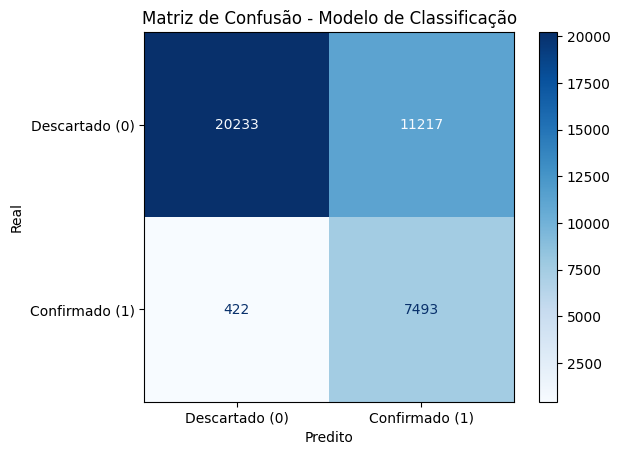

In [30]:
# Gerar a matriz de confusão
cm = confusion_matrix(y_test, y_pred_ajustado)

# Rótulos legíveis para o gráfico
labels = ['Descartado (0)', 'Confirmado (1)']

# Plotar a matriz
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
disp.plot(cmap='Blues', values_format='d')

plt.title("Matriz de Confusão - Modelo de Classificação")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.show()


### Métricas

In [10]:

# Calcular todas as métricas
metrics = {
    'Accuracy': accuracy_score(y_test, y_pred),
    'Balanced Accuracy': balanced_accuracy_score(y_test, y_pred),
    'Precision': precision_score(y_test, y_pred, zero_division=0),
    'Recall (Sensibilidade)': recall_score(y_test, y_pred, zero_division=0),
    'Especificidade': recall_score(y_test, y_pred, pos_label=0, zero_division=0),
    'F1 Score': f1_score(y_test, y_pred, zero_division=0),
    'ROC AUC': roc_auc_score(y_test, y_proba) if len(np.unique(y_test)) == 2 else np.nan,
    'Brier Score': brier_score_loss(y_test, y_proba),
    'Log Loss': log_loss(y_test, y_proba),
    'MCC (Matthews Corr)': matthews_corrcoef(y_test, y_pred),
    'Kappa de Cohen': cohen_kappa_score(y_test, y_pred)
}

# Converter para DataFrame
df_metrics = pd.DataFrame(metrics, index=['Valor']).T
df_metrics.columns = ['Métrica']
df_metrics = df_metrics.rename_axis('Indicador').reset_index()

# Exibir
print(df_metrics)


                 Indicador   Métrica
0                 Accuracy  0.924400
1        Balanced Accuracy  0.850719
2                Precision  0.875475
3   Recall (Sensibilidade)  0.727479
4           Especificidade  0.973959
5                 F1 Score  0.794645
6                  ROC AUC  0.938899
7              Brier Score  0.060528
8                 Log Loss  0.217453
9      MCC (Matthews Corr)  0.753622
10          Kappa de Cohen  0.748801


### Features importance

In [11]:
# Acessar o primeiro modelo calibrado (há um por fold)
lgbm_model = clf.named_steps['model'].calibrated_classifiers_[0].estimator
importances = lgbm_model.feature_importances_
feature_names = clf.named_steps['preprocess'].get_feature_names_out()


In [12]:
import pandas as pd
feature_importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': importances
}).sort_values(by='importance', ascending=False)

print(feature_importance_df.head(10))


                            feature  importance
1634          remainder__NU_IDADE_N        1747
1639        remainder__mes_sintomas         672
1518  cat__CON_AMBIEN_Não informado         323
1512    cat__CON_AREA_Não informado         210
1577            cat__CLI_ICTERI_Sim         207
1622                  cat__SG_UF_RS         205
1568            cat__CLI_PANTUR_Sim         185
1615                  cat__SG_UF_PE         184
1575            cat__CLI_ICTERI_Não         183
1625                  cat__SG_UF_SP         175


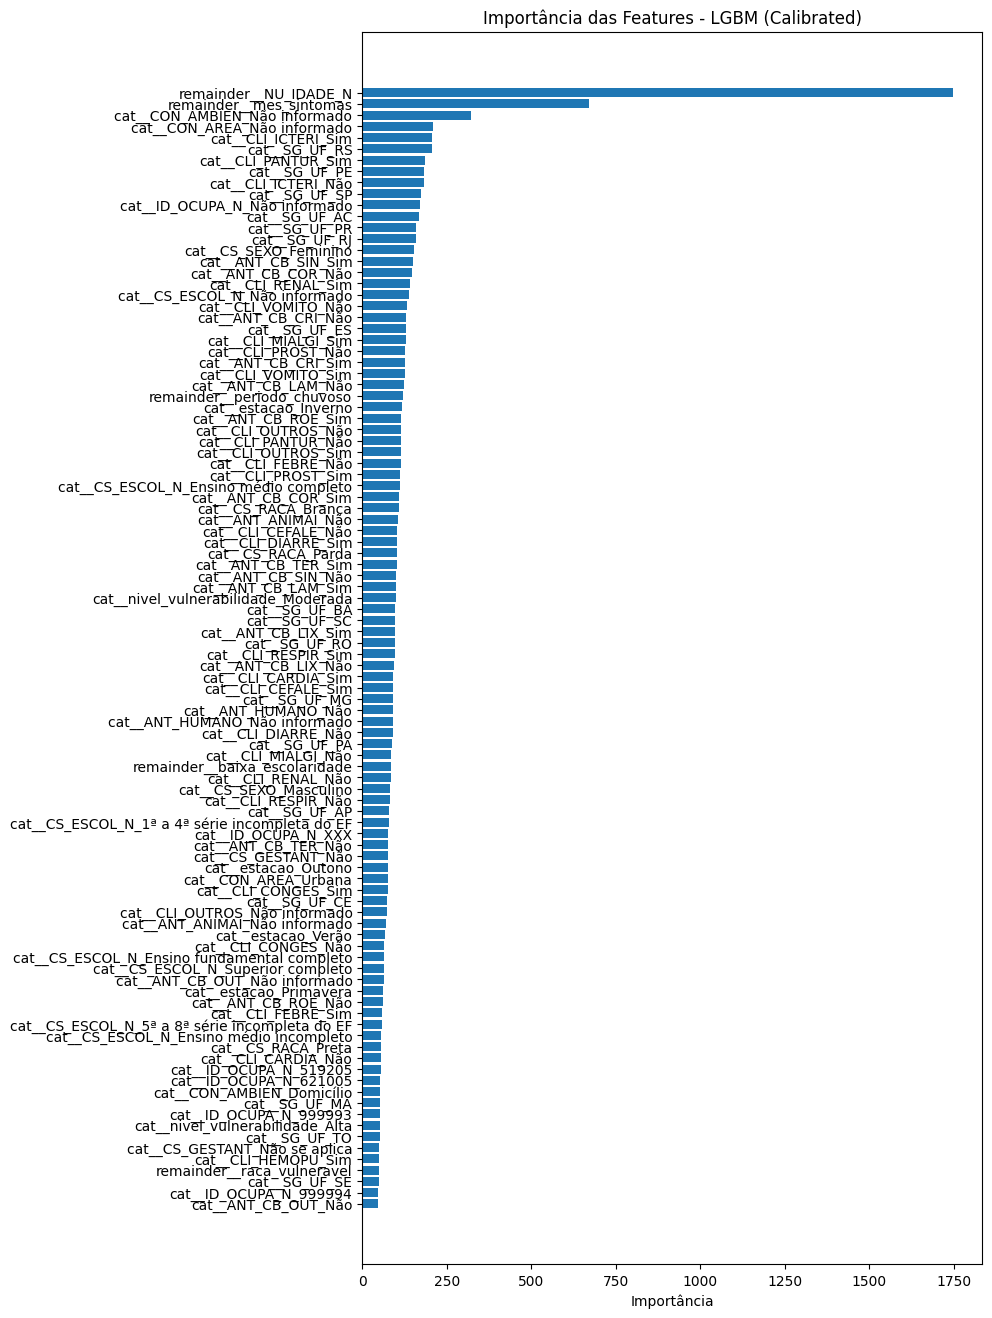

In [18]:
import matplotlib.pyplot as plt

top_features = feature_importance_df.head(100)
plt.figure(figsize=(8,16))
plt.barh(top_features['feature'], top_features['importance'])
plt.gca().invert_yaxis()
plt.title("Importância das Features - LGBM (Calibrated)")
plt.xlabel("Importância")
plt.show()
